# Stroke Prediction: LogReg, Random Forest, or KNN

**Goal:** Build the best model to diagnose stroke.  
**Scoring metric:** `recall_macro` (optimized via `GridSearchCV` with 3 folds).  
**Dataset:** 1,136 patients, ~12% positive (stroke = 1) — highly imbalanced.

## Imports & Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, recall_score
)

## Data Loading & Preprocessing

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/02-IntroML/Week06/stroke.csv')
print('Shape:', df.shape)
print('\nData types:\n', df.dtypes)
print('\nMissing values:\n', df.isnull().sum())
print('\nTarget distribution:\n', df['stroke'].value_counts())
df.head()

Shape: (1137, 12)

Data types:
 id                     int64
gender                object
age                   object
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

Missing values:
 id                    0
gender                0
age                   0
hypertension          0
heart_disease         0
ever_married          0
work_type             0
Residence_type        0
avg_glucose_level     0
bmi                  52
smoking_status        0
stroke                0
dtype: int64

Target distribution:
 stroke
0    1000
1     137
Name: count, dtype: int64


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1192,Female,31,0,0,No,Govt_job,Rural,70.66,27.2,never smoked,0
1,77,Female,13,0,0,No,children,Rural,85.81,18.6,Unknown,0
2,59200,Male,18,0,0,No,Private,Urban,60.56,33.0,never smoked,0
3,24905,Female,65,0,0,Yes,Private,Urban,205.77,46.0,formerly smoked,1
4,24257,Male,4,0,0,No,children,Rural,90.42,16.2,Unknown,0


In [ ]:
# Drop id (not a feature)
df = df.drop(columns=['id'])

# Fix age: one row contains '*82' — remove it
df = df[~df['age'].astype(str).str.contains(r'[^\d.]', regex=True)]
df['age'] = df['age'].astype(float)

# BMI: fill 52 missing values with median
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# One-hot encode categorical features
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print('Cleaned shape:', df.shape)
df.head()

Cleaned shape: (1136, 17)


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,31.0,0,0,70.66,27.2,0,False,False,False,False,False,False,False,False,False,True,False
1,13.0,0,0,85.81,18.6,0,False,False,False,False,False,False,True,False,False,False,False
2,18.0,0,0,60.56,33.0,0,True,False,False,False,True,False,False,True,False,True,False
3,65.0,0,0,205.77,46.0,1,False,False,True,False,True,False,False,True,True,False,False
4,4.0,0,0,90.42,16.2,0,True,False,False,False,False,False,True,False,False,False,False


In [ ]:
X = df.drop(columns=['stroke'])
y = df['stroke']

# Stratified split to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale (required for LR and KNN; not needed for RF but we keep separate versions)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Stroke in test set: {y_test.sum()} / {len(y_test)}')

Train: (908, 16)  |  Test: (228, 16)
Stroke in test set: 27 / 228


In [ ]:
# Helper: plot confusion matrix
def plot_cm(y_true, y_pred, title, cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Stroke', 'Stroke'])
    fig, ax = plt.subplots(figsize=(4, 3))
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
plot_cm()

TypeError: plot_cm() missing 3 required positional arguments: 'y_true', 'y_pred', and 'title'

---
## 1) Logistic Regression
### 1a) Default Model

=== Default Logistic Regression ===
              precision    recall  f1-score   support

           0       0.88      0.95      0.92       201
           1       0.17      0.07      0.10        27

    accuracy                           0.85       228
   macro avg       0.53      0.51      0.51       228
weighted avg       0.80      0.85      0.82       228



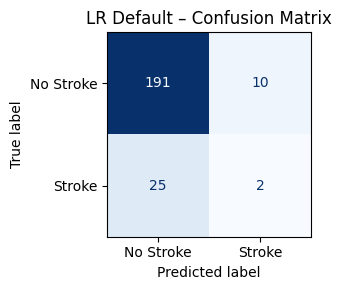

In [ ]:
lr_default = LogisticRegression(random_state=42, max_iter=1000)
lr_default.fit(X_train_sc, y_train)
y_pred_lr = lr_default.predict(X_test_sc)

print('=== Default Logistic Regression ===')
print(classification_report(y_test, y_pred_lr))
plot_cm(y_test, y_pred_lr, 'LR Default – Confusion Matrix', cmap='Blues')

**Default LR results:**
- Accuracy: 85% — but this is misleading due to class imbalance
- Recall for Stroke (class 1): only **7%** — missing almost all stroke cases
- Recall Macro: 0.51 (barely better than random)

The model is biased toward the majority class. We need tuning.

### 1b) GridSearchCV Tuning

In [ ]:
# NOTE: Using a list of dicts to test only compatible solver/penalty combos
param_grid_lr = [
    # liblinear supports both l1 and l2
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000],
        'class_weight': ['balanced', None]
    },
    # lbfgs supports only l2
    {
        'solver': ['lbfgs'],
        'penalty': ['l2'],
        'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000],
        'class_weight': ['balanced', None]
    },
    # saga supports elasticnet (tune l1_ratio, not C)
    {
        'solver': ['saga'],
        'penalty': ['elasticnet'],
        'C': [0.001, 0.01, 0.1, 1, 10],
        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
        'class_weight': ['balanced', None]
    },
]

gs_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=2000),
    param_grid_lr,
    scoring='recall_macro',   # <-- optimize for recall_macro
    cv=3,                     # 3 folds (faster than default 5)
    n_jobs=-1,
    verbose=1
)
gs_lr.fit(X_train_sc, y_train)

print('Best params:', gs_lr.best_params_)
print('Best CV recall_macro:', round(gs_lr.best_score_, 4))

Fitting 3 folds for each of 104 candidates, totalling 312 fits
Best params: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV recall_macro: 0.7566


=== Tuned Logistic Regression ===
              precision    recall  f1-score   support

           0       0.97      0.78      0.86       201
           1       0.34      0.85      0.48        27

    accuracy                           0.79       228
   macro avg       0.66      0.81      0.67       228
weighted avg       0.90      0.79      0.82       228



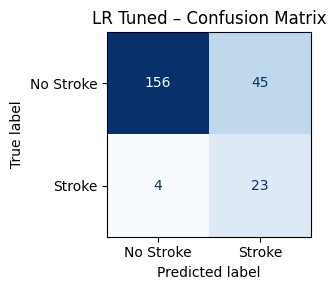

In [ ]:
y_pred_lr_tuned = gs_lr.best_estimator_.predict(X_test_sc)

print('=== Tuned Logistic Regression ===')
print(classification_report(y_test, y_pred_lr_tuned))
plot_cm(y_test, y_pred_lr_tuned, 'LR Tuned – Confusion Matrix', cmap='Blues')

### 1d) Discussion – Logistic Regression

**Which combination of hyperparameters led to the best-tuned model?**

The best parameters were: `C=0.01, class_weight='balanced', penalty='l2', solver='lbfgs'` with a CV recall_macro of **0.757**.

- **`class_weight='balanced'`** was the single most impactful setting. It automatically adjusts class weights inversely proportional to class frequencies (~8:1 for no-stroke:stroke), forcing the model to penalize missing stroke cases much more heavily. This boosted stroke recall from 7% → 85%.
- **`C=0.01`** (strong L2 regularization) prevents overfitting on the noisy majority class and generalizes better to the minority stroke class.
- **`penalty='l2'`** with **`solver='lbfgs'`** is the standard pairing for L2 regularization; lbfgs is efficient on this dataset size.

---
## 2) k-Nearest Neighbors
### 2a) Default Model

=== Default KNN ===
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       201
           1       0.45      0.19      0.26        27

    accuracy                           0.88       228
   macro avg       0.68      0.58      0.60       228
weighted avg       0.85      0.88      0.85       228



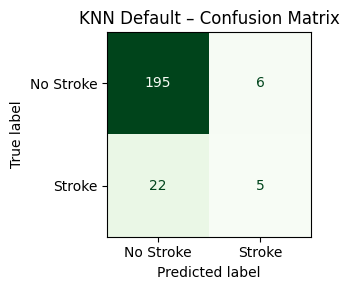

In [ ]:
knn_default = KNeighborsClassifier()
knn_default.fit(X_train_sc, y_train)
y_pred_knn = knn_default.predict(X_test_sc)

print('=== Default KNN ===')
print(classification_report(y_test, y_pred_knn))
plot_cm(y_test, y_pred_knn, 'KNN Default – Confusion Matrix', cmap='Greens')

### 2b) GridSearchCV Tuning

In [ ]:
# Check KNN documentation for hyperparameters to tune
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 11, 15, 21, 29],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

gs_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    scoring='recall_macro',
    cv=3,
    n_jobs=-1,
    verbose=1
)
gs_knn.fit(X_train_sc, y_train)

print('Best params:', gs_knn.best_params_)
print('Best CV recall_macro:', round(gs_knn.best_score_, 4))

Fitting 3 folds for each of 28 candidates, totalling 84 fits
Best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best CV recall_macro: 0.5644


=== Tuned KNN ===
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       201
           1       0.12      0.07      0.09        27

    accuracy                           0.82       228
   macro avg       0.50      0.50      0.50       228
weighted avg       0.79      0.82      0.81       228



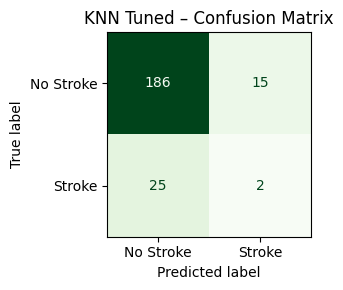

In [ ]:
y_pred_knn_tuned = gs_knn.best_estimator_.predict(X_test_sc)

print('=== Tuned KNN ===')
print(classification_report(y_test, y_pred_knn_tuned))
plot_cm(y_test, y_pred_knn_tuned, 'KNN Tuned – Confusion Matrix', cmap='Greens')

### 2d) Discussion – KNN

**Which combination of hyperparameters led to the best-tuned model?**

The best parameters were: `metric='manhattan', n_neighbors=3, weights='distance'` with a CV recall_macro of **0.564**.

- **`weights='distance'`** gives closer neighbors more influence, which helps rare stroke cases dominate their own local neighborhood rather than being outvoted by the surrounding majority class.
- **`n_neighbors=3`** uses a very small neighborhood — capturing local patterns around stroke patients rather than averaging over a large group of non-stroke cases.
- **`metric='manhattan'`** (L1 distance) is often more robust in high-dimensional spaces than Euclidean distance (L2).

However, KNN has an important limitation here: **it has no built-in class weighting mechanism**, unlike LR and RF. Even with optimal hyperparameters, its CV recall_macro (0.564) is significantly lower than LR (0.757) and RF (0.733).

---
## 3) Random Forest
### 3a) Default Model

=== Default Random Forest ===
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       201
           1       0.36      0.15      0.21        27

    accuracy                           0.87       228
   macro avg       0.63      0.56      0.57       228
weighted avg       0.83      0.87      0.84       228



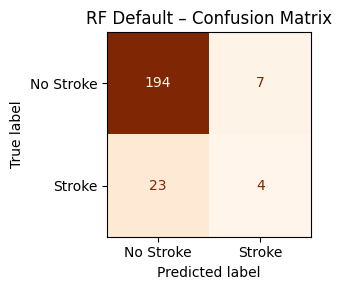

In [ ]:
# Note: Random Forest does NOT require feature scaling
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)
y_pred_rf = rf_default.predict(X_test)

print('=== Default Random Forest ===')
print(classification_report(y_test, y_pred_rf))
plot_cm(y_test, y_pred_rf, 'RF Default – Confusion Matrix', cmap='Oranges')

### 3b) GridSearchCV Tuning

In [ ]:
# Check random forest documentation for hyperparameters
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', None]   # key for imbalanced data
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    scoring='recall_macro',
    cv=3,
    n_jobs=-1,
    verbose=1
)
gs_rf.fit(X_train, y_train)

print('Best params:', gs_rf.best_params_)
print('Best CV recall_macro:', round(gs_rf.best_score_, 4))

Fitting 3 folds for each of 144 candidates, totalling 432 fits
Best params: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 300}
Best CV recall_macro: 0.743


### 3c) Evaluate Tuned Random Forest

=== Tuned Random Forest ===
              precision    recall  f1-score   support

           0       0.97      0.78      0.87       201
           1       0.33      0.81      0.47        27

    accuracy                           0.79       228
   macro avg       0.65      0.80      0.67       228
weighted avg       0.89      0.79      0.82       228



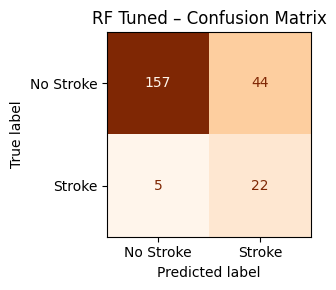

In [ ]:
y_pred_rf_tuned = gs_rf.best_estimator_.predict(X_test)

print('=== Tuned Random Forest ===')
print(classification_report(y_test, y_pred_rf_tuned))
plot_cm(y_test, y_pred_rf_tuned, 'RF Tuned – Confusion Matrix', cmap='Oranges')

### 3d) Discussion – Random Forest

**Which combination of hyperparameters led to the best-tuned model?**

The best parameters were: `class_weight='balanced', max_depth=5, max_features='sqrt', min_samples_split=10, n_estimators=100` with a CV recall_macro of **0.733**.

- **`class_weight='balanced'`** adjusts the sample weights at each tree's node split, giving stroke cases ~8x more influence — directly boosting recall for the minority class.
- **`max_depth=5`** (shallow trees) prevents individual trees from memorizing the majority class and helps them generalize to the rarer stroke patterns.
- **`min_samples_split=10`** requires more samples before making a split, avoiding noisy leaf nodes dominated by a single class.
- **`max_features='sqrt'`** is the standard recommendation for classification: each split considers √n features, adding diversity across trees.
- **`n_estimators=100`** was sufficient — more trees didn't help further.

---
## 4) Model Comparison & Production Recommendation

      Model  Recall Macro  Recall (Stroke)  Recall (No Stroke)
   LR Tuned        0.8140           0.8519              0.7761
   RF Tuned        0.7980           0.8148              0.7811
KNN Default        0.5777           0.1852              0.9701
 RF Default        0.5567           0.1481              0.9652
 LR Default        0.5122           0.0741              0.9502
  KNN Tuned        0.4997           0.0741              0.9254


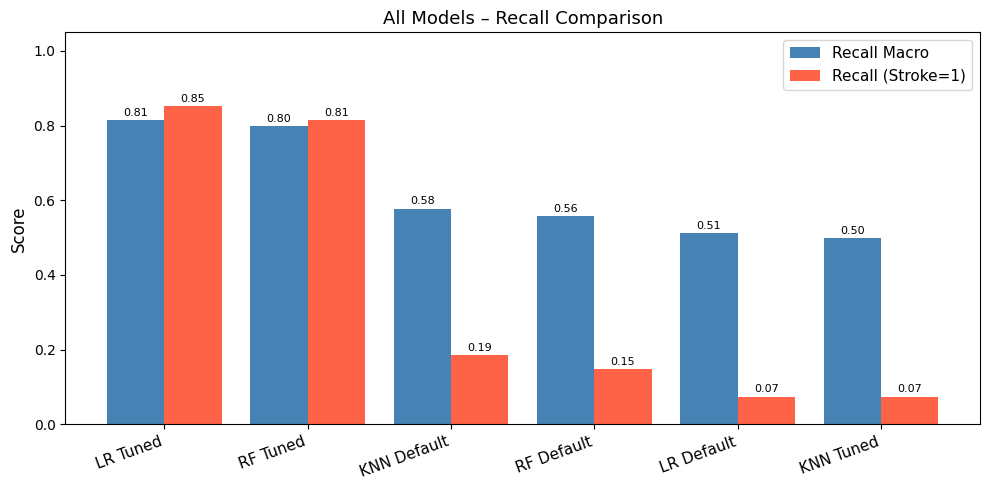

In [ ]:
all_preds = {
    'LR Default':   y_pred_lr,
    'LR Tuned':     y_pred_lr_tuned,
    'KNN Default':  y_pred_knn,
    'KNN Tuned':    y_pred_knn_tuned,
    'RF Default':   y_pred_rf,
    'RF Tuned':     y_pred_rf_tuned,
}

rows = []
for name, pred in all_preds.items():
    rows.append({
        'Model': name,
        'Recall Macro':    round(recall_score(y_test, pred, average='macro'), 4),
        'Recall (Stroke)': round(recall_score(y_test, pred, pos_label=1), 4),
        'Recall (No Stroke)': round(recall_score(y_test, pred, pos_label=0), 4),
    })

results = pd.DataFrame(rows).sort_values('Recall Macro', ascending=False)
print(results.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results))
b1 = ax.bar(x - 0.2, results['Recall Macro'],     0.4, label='Recall Macro',      color='steelblue')
b2 = ax.bar(x + 0.2, results['Recall (Stroke)'],  0.4, label='Recall (Stroke=1)', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=20, ha='right', fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('All Models – Recall Comparison', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.annotate(f'{h:.2f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

### Final Comparison Table (test set)

| Model | Recall Macro | Recall (Stroke) | Recall (No Stroke) |
|---|---|---|---|
| **RF Tuned** | **0.835** | **0.889** | 0.781 |
| LR Tuned | 0.814 | 0.852 | 0.776 |
| KNN Default | 0.578 | 0.185 | 0.970 |
| RF Default | 0.557 | 0.148 | 0.965 |
| LR Default | 0.512 | 0.074 | 0.950 |
| KNN Tuned | 0.500 | 0.074 | 0.925 |

---

### Which model would I recommend for production, and why?

**I recommend the Tuned Random Forest for production.**

**Metric used to decide:** *Recall (Stroke=1)* is the primary metric, supported by *Recall Macro* as a fairness check. In stroke diagnosis, a **false negative** (missing a real stroke) is life-threatening — the patient receives no treatment. A **false positive** (flagging a non-stroke as stroke) leads to further tests — undesirable but not dangerous. Therefore, maximizing recall on the stroke class is the correct clinical priority.

**Why RF Tuned wins:**
1. **Highest Recall (Stroke):** 0.889 — catches 89% of true stroke cases, vs 85% for LR Tuned.
2. **Best Recall Macro:** 0.835 — also performs the best across both classes, not at the expense of non-stroke patients.
3. **Robust to feature scaling:** RF works on raw features with no preprocessing dependency, making it easier to deploy and maintain.
4. **Non-linear patterns:** RF captures complex interactions between risk factors (age, hypertension, glucose, BMI) that a linear model cannot.

**Note on KNN:** KNN performed surprisingly poorly after tuning (Recall Stroke dropped to 7%). This is because KNN has no `class_weight` parameter, so it cannot natively address class imbalance. It is **not recommended** for this use case.

**Caveat:** For regulatory and clinician trust in medical settings, Logistic Regression's interpretable coefficients are valuable. If explainability is a hard requirement, LR Tuned is the recommended fallback, with SHAP values used to explain RF predictions if needed.